### Import and Load the Dataset

In [3]:
import pandas as pd
import os

BoT_IoT_path = "/kaggle/input/bot-iot-5-data/"
df = pd.DataFrame()

for dirname, _, filenames in os.walk(BoT_IoT_path):
    for filename in filenames:
        temp_df = pd.read_csv(os.path.join(dirname, filename), low_memory = False)
        df = pd.concat([df, temp_df], axis = 0, ignore_index = True)

### Balic Information of Dataset

In [4]:
# Basic info
print("Dataset Shape: ",df.shape)
df.head()

Dataset Shape:  (3668522, 46)


,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
0,1000001,1.528085e+09,e,1,udp,3,192.168.100.148,37153,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP
1,1000002,1.528085e+09,e,1,udp,3,192.168.100.148,37154,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP
2,1000003,1.528085e+09,e,1,udp,3,192.168.100.148,37155,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP
3,1000004,1.528085e+09,e,1,udp,3,192.168.100.148,37156,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP
4,1000005,1.528085e+09,e,1,udp,3,192.168.100.148,37157,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3668522 entries, 0 to 3668521
Data columns (total 46 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   pkSeqID                           int64  
 1   stime                             float64
 2   flgs                              object 
 3   flgs_number                       int64  
 4   proto                             object 
 5   proto_number                      int64  
 6   saddr                             object 
 7   sport                             object 
 8   daddr                             object 
 9   dport                             object 
 10  pkts                              int64  
 11  bytes                             int64  
 12  state                             object 
 13  state_number                      int64  
 14  ltime                             float64
 15  seq                               int64  
 16  dur                               fl

In [6]:
df.isnull().sum()

pkSeqID                             0
stime                               0
flgs                                0
flgs_number                         0
proto                               0
proto_number                        0
saddr                               0
sport                               0
daddr                               0
dport                               0
pkts                                0
bytes                               0
state                               0
state_number                        0
ltime                               0
seq                                 0
dur                                 0
mean                                0
stddev                              0
sum                                 0
min                                 0
max                                 0
spkts                               0
dpkts                               0
sbytes                              0
dbytes                              0
rate        

In [7]:
# Get the unique values in the specified column
unique_category = df['category'].unique()
unique_subcategory = df['subcategory'].unique()
unique_attack = df['attack'].unique()

# Print the unique values
print("Categories: ",unique_category)
print("Subcategories: ",unique_subcategory)
print("Attack: ",unique_attack)

Categories:  ['DoS' 'DDoS' 'Normal' 'Reconnaissance' 'Theft']
Subcategories:  ['UDP' 'HTTP' 'TCP' 'Normal' 'OS_Fingerprint' 'Service_Scan'
 'Data_Exfiltration' 'Keylogging']
Attack:  [1 0]


In [8]:
print(df.dtypes)

pkSeqID                               int64
stime                               float64
flgs                                 object
flgs_number                           int64
proto                                object
proto_number                          int64
saddr                                object
sport                                object
daddr                                object
dport                                object
pkts                                  int64
bytes                                 int64
state                                object
state_number                          int64
ltime                               float64
seq                                   int64
dur                                 float64
mean                                float64
stddev                              float64
sum                                 float64
min                                 float64
max                                 float64
spkts                           

In [9]:
# Separate features and target
X = df.drop(['category', 'attack', 'subcategory'], axis=1)
y = df['category']

In [11]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Iterate over object type columns in X
for col in X.select_dtypes(include=['object']):
    # Fit and transform the column
    X[col] = le.fit_transform(X[col])

In [12]:
print(X.dtypes)

pkSeqID                               int64
stime                               float64
flgs                                  int64
flgs_number                           int64
proto                                 int64
proto_number                          int64
saddr                                 int64
sport                                 int64
daddr                                 int64
dport                                 int64
pkts                                  int64
bytes                                 int64
state                                 int64
state_number                          int64
ltime                               float64
seq                                   int64
dur                                 float64
mean                                float64
stddev                              float64
sum                                 float64
min                                 float64
max                                 float64
spkts                           

In [13]:
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [14]:
# Final preprocessed dataset
X_processed = X_scaled
y_processed = y

# Optional: check class balance
print(y_processed.value_counts())

category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79
Name: count, dtype: int64


In [15]:
# Concat X_processed and y_processed into a single DataFrame
combined_df = pd.concat([X_processed, y_processed], axis=1)

# Display the combined DataFrame
combined_df.head()


,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,category
0,-0.787773,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146527,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS
1,-0.787772,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146474,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS
2,-0.787771,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146421,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS
3,-0.787770,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146368,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS
4,-0.787769,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146316,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS


In [16]:
# Save the combined DataFrame to a CSV file
combined_df.to_csv("/kaggle/working/bot_iot_5_preprocessed_dataset.csv", index=False)
print("Dataframe saved to a CSV file")

Dataframe saved to a CSV file


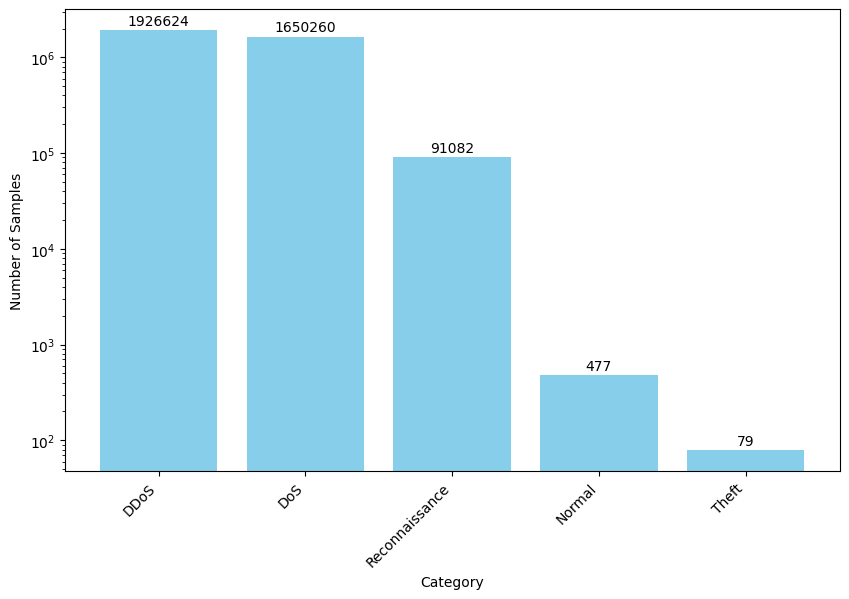

In [17]:
# Distribution of Samples across Categories
import matplotlib.pyplot as plt
import numpy as np  # Import numpy for log calculations

# Data
categories = ['DDoS', 'DoS', 'Reconnaissance', 'Normal', 'Theft']
num_samples = [1926624, 1650260, 91082, 477, 79]

# Create bar graph
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.bar(categories, num_samples, color='skyblue')

# Add labels and title
plt.xlabel("Category")
plt.ylabel("Number of Samples")

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45, horizontalalignment='right')

# Add sample count above each bar with relative offset
for i, v in enumerate(num_samples):
    offset = v * 0.05  # 5% of the bar height as offset
    plt.text(i, v + offset, str(v), ha='center', va='bottom')

# Set y-axis to logarithmic scale
plt.yscale('log')

# Save the figure
plt.savefig('distribution_of_samples.png')  # Specify filename and format

# Display the graph (optional)
plt.show()

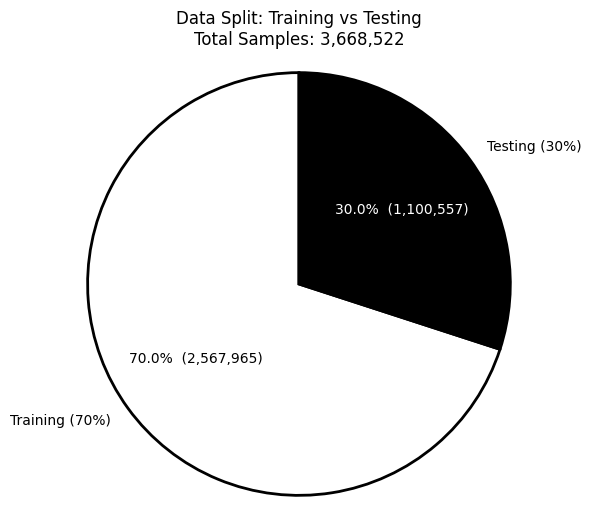

In [2]:
import matplotlib.pyplot as plt

# Total number of samples
total_samples = 3668522

# Calculate training and testing sample sizes
train_samples = int(0.7 * total_samples)
test_samples = total_samples - train_samples

# Labels and sizes
labels = ['Training (70%)', 'Testing (30%)']
sizes = [train_samples, test_samples]
colors = ['#ffffff', '#000000']

# Custom function to format labels
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.1f}%  ({v:,})'.format(p=pct,v=val)
    return my_autopct

# Plot
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=90, colors=colors,
                                  wedgeprops={'edgecolor': 'black', 'linewidth': 2})  # Add border
plt.title(f'Data Split: Training vs Testing\nTotal Samples: {total_samples:,}')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.

# Set text color for the testing slice to white
for autotext in autotexts[1:]: # Selecting the second element and onwards (Testing)
    autotext.set_color('white')

# Save the figure 
plt.savefig('data_split_pie_chart.png')  # You can change the filename and extension

plt.show()